In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

sys.path.append('../../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

## Load Norman 2019 data

Norman et al. 2019 (CRISPRa screen) — 105 single and 131 double perturbations in K562 cells.  
`slk_prepare_data` standardises the perturbation column to `obs['pert']` with NTC → `'NTC'`.

In [3]:
data = sc.read_h5ad("../../datasets/norman/Norman_2019.h5ad")
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f"Cells: {data.n_obs}   Genes: {data.n_vars}")
print(f"Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}")

Cells: 111255   Genes: 19018
Single perts: 105   Combo perts: 131   NTC cells: 11835


## Gene filtering

Keep highly variable genes (seurat_v3, top 2000) **plus** any gene that appears as a perturbation target (single or split from combo) **plus** the top 10 DEGs (by |mean log-normalised expression − NTC|) for every perturbation. This reduces the feature space while ensuring every perturbed gene and its strongest downstream effects are retained.

In [4]:
import scipy.sparse as sp

# Collect all individual gene names that appear as perturbation targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

# Norman 2019: use all genes with mean expression > 0.5 UMI per cell (~2800 genes).
# data.X still holds raw counts at this point.
raw_X = data.X
mean_expr = np.array(raw_X.mean(axis=0)).flatten()
expr_mask = mean_expr > 0.5

# Always keep perturbation target genes so their expression is available.
pert_mask = data.var_names.isin(pert_genes)
keep_mask = expr_mask | pert_mask
data = data[:, keep_mask].copy()

n_expr     = int(expr_mask[keep_mask].sum())
n_pert_only = int((pert_mask[keep_mask] & ~expr_mask[keep_mask]).sum())
print(f"Kept {data.n_vars} genes  ({n_expr} with mean > 0.5 UMI + {n_pert_only} pert-only)")
print(f"Pert genes in var_names: {pert_mask[keep_mask].sum()} / {len(pert_genes)}")


Kept 3270 genes  (3190 with mean > 0.5 UMI + 80 pert-only)
Pert genes in var_names: 102 / 105


In [5]:
# top_deg = 10
# # Collect all individual gene names that appear as perturbation targets
# pert_genes = set()
# for p in all_perts:
#     if p != NTC:
#         for g in str(p).split('+'):
#             pert_genes.add(g.strip())

# # HVG selection on raw counts (seurat_v3 expects counts in X)
# sc.pp.highly_variable_genes(data, n_top_genes=2000, flavor='seurat_v3', subset=False)

# # Top-10 DEGs per perturbation (computed on log-normalised copy before subsetting)
# _tmp = data.copy()
# sc.pp.normalize_total(_tmp, target_sum=1e4)
# sc.pp.log1p(_tmp)
# X_norm = _tmp.X.toarray() if hasattr(_tmp.X, 'toarray') else _tmp.X
# ntc_mean = X_norm[(_tmp.obs[p_key] == NTC).values].mean(axis=0)
# deg_genes = set()
# for p in all_perts:
#     if p == NTC:
#         continue
#     mask = (_tmp.obs[p_key] == p).values
#     if mask.sum() == 0:
#         continue
#     lfc = np.abs(X_norm[mask].mean(0) - ntc_mean)
#     deg_genes.update(_tmp.var_names[np.argsort(lfc)[-top_deg:]])
# del _tmp

# # Union: HVG OR perturbation target OR top-10 DEG for any perturbation
# pert_mask = data.var_names.isin(pert_genes)
# deg_mask  = data.var_names.isin(deg_genes)
# keep_mask = data.var['highly_variable'] | pert_mask #| deg_mask TODO ADD FOR DEG
# data = data[:, keep_mask].copy()

# n_hvg      = data.var['highly_variable'].sum()
# n_pert_only = (pert_mask[keep_mask] & ~data.var['highly_variable']).sum()
# n_deg_only  = (deg_mask[keep_mask] & ~data.var['highly_variable'] & ~pert_mask[keep_mask]).sum()
# print(f"Kept {data.n_vars} genes  ({n_hvg} HVG + {n_pert_only} pert-only + {n_deg_only} DEG-only)")
# print(f"Pert genes in var_names: {pert_mask[keep_mask].sum()} / {len(pert_genes)}")

## Compute treatment effects

Ground-truth per-perturbation mean effects (log2-CPM vs NTC), computed for all labels including combinations.

In [6]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f"treat_effect: {te.n_obs} perturbations × {te.n_vars} genes")
print(f"  single: {sum('+' not in p and p != NTC for p in te.obs_names)}   combo: {sum('+' in p for p in te.obs_names)}")

100%|██████████| 236/236 [00:04<00:00, 52.53it/s]

treat_effect: 236 perturbations × 3270 genes
  single: 105   combo: 131


## Train VAE (combinatorial mode)

Architecture:
- **Encoder** — background `z0` via `z0_encoder` on NTC; perturbed `z` via shared `z_encoder`
- **Gate** `W[p]` (HardConcrete, shape P×d) — sparse binary mask over latent dims
- **Shift** `z = z0*(1 − W[p]) + A[p]*W[p]` — mechanism shift only in gated dims (linear mode)
- **Decoder** — perturbation-agnostic NB decoder
- **Combinatorial** — labels like `GENE1+GENE2` are split; component shifts are summed at training time
- **Counterfactuals** — abduct NTC `z0`, K-means centroids, apply union(W) gate + Σ A_j*W_j shift

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [8]:
# ── Training split: hold out ceil(20%) of each Norman GT class ──────────
import math, random

random.seed(42)
gi = pd.read_csv('./genetic_interactions.csv')

def canon(s):
    a, b = s.split('+')
    return '+'.join(sorted([a, b]))

gi['combination'] = gi['combination'].apply(canon)
gi['genetic_interaction'] = gi['genetic_interaction'].str.strip()

# For each class, hold out ceil(20%) as validation
val_combos = set()
for cls, grp in gi.groupby('genetic_interaction'):
    n_val = math.ceil(0.2 * len(grp))
    chosen = random.sample(list(grp['combination']), n_val)
    val_combos.update(chosen)

print(f'Total GT pairs: {len(gi)}  |  Held-out val: {len(val_combos)}')

# Build val mask: cells whose combo perturbation is in val_combos
p_key = slk.configs.get_config('pert_key')

def is_val_combo(pert):
    if '+' not in pert:
        return False
    return canon(pert) in val_combos

val_mask = data.obs[p_key].apply(is_val_combo)
data_train = data[~val_mask].copy()
print(f'data shape: {data.shape}  |  data_train shape: {data_train.shape}')
print(f'Val combos held out: {val_combos}')


Total GT pairs: 88  |  Held-out val: 22
data shape: (111255, 3270)  |  data_train shape: (104626, 3270)
Val combos held out: {'MAP2K6+SPI1', 'ETS2+PRTG', 'FOXA1+FOXL2', 'FOSB+OSR2', 'MAP2K3+MAP2K6', 'CEBPB+PTPN12', 'MAPK1+PRTG', 'FEV+MAP7D1', 'CBL+CNN1', 'DLX2+SNAI1', 'PRTG+TGFBR2', 'SAMD1+UBASH3B', 'DUSP9+PRTG', 'PTPN12+UBASH3A', 'PTPN9+UBASH3B', 'CEBPE+SPI1', 'PTPN12+UBASH3B', 'CEBPA+ZC3HAV1', 'KLF1+TGFBR2', 'OSR2+PTPN12', 'DUSP9+SNAI1', 'BPGM+SAMD1'}


Training VAE on cuda …


Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

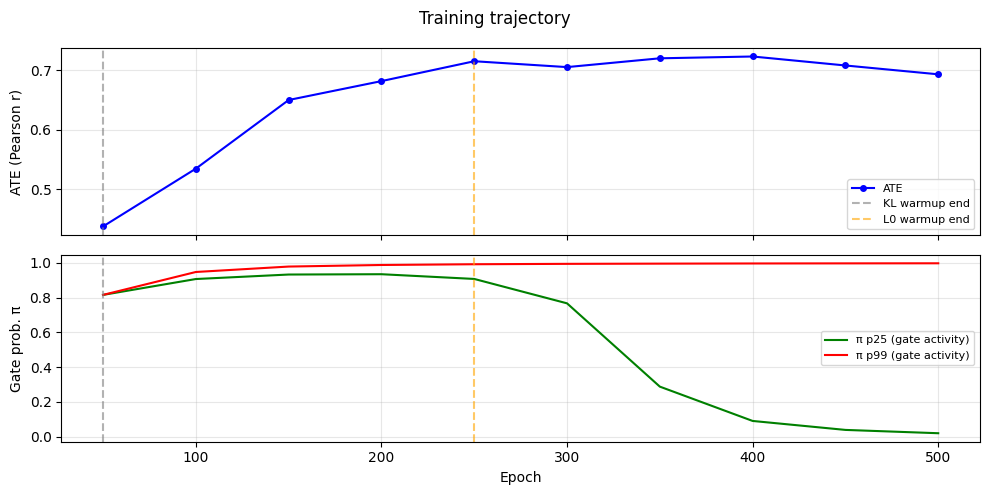

In [9]:
results = slk.tl.run_single(
    data_train,
    model='vae',
    # batch_size=2048,
    # ce_lambda=1e-1,
    l0_lambda=25, #20
    # l1_lambda=10.,
    rank=6,
    shuffle=True,
    num_workers=0,
    device=device,
    # latent_dim=16,
    num_epochs=500,
    validate_every=50,
    patience=15,
    combinatorial=True,
    debug=True,
    synergy=True,
    synergy_rank=6,
    n_epochs_l0_warmup=200
    # n_epochs_kl_warmup=20
)
model = results['model']

## Save & load

In [10]:
file_name = "norman_vae"

In [11]:
os.makedirs('../results', exist_ok=True)
slk.tl.save_results(results, f'../results/{file_name}.pth')

In [12]:
model = slk.tl.load_results(f'../results/{file_name}.pth')
print(type(model))

<class 'sherlock.tools._models.VAE'>


## Evaluate

`z` — perturbed latent per cell.  
`rho_corr` — Pearson correlation of Cholesky-structured `A[p]` vectors.  
For z_corr, only single-perturbation cells are used.

In [13]:
slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=device)
print(list(data.uns['results'].keys()))

['z_corr', 'z_perts', 'z_embed', 'rho_corr', 'rho_perts', 'rho_embed', 'acc', 'z_rho_corr', 'W', 'synergy_enabled', 'synergy_rank', 'counterfactual_effect_size', 'condition_perturbation_interaction', 'conditions', 'synergy_pair_names', 'synergy_pair_norm', 'parent_scale_a', 'parent_scale_b']


In [26]:
syn = model.get_gi(
    data,
    obsm_key='z',
    min_cells=5,
    observed=True
)

get_gi:   0%|          | 0/131 [00:00<?, ?pair/s]

In [15]:
syn.to_csv('./results/syn_unseen.csv', index=True)

In [16]:
import importlib
import sherlock.tools._gears as gears_tools
import sherlock.tools._models as models_tools

importlib.reload(gears_tools)
importlib.reload(models_tools)

slk.tl.classify_gi = models_tools.classify_gi

slk.tl.run_gears_gi = gears_tools.run_gears_gi
slk.tl.train_gears = gears_tools.train_gears
slk.tl.predict_gears_combinations = gears_tools.predict_gears_combinations


## GEARS genetic interaction prediction


In [19]:
gears_combos = slk.tl.get_observed_combinations(
    data,
    pert_key=p_key,
    ntc_label=NTC,
)

gears_run = slk.tl.run_gears_gi(
    data,
    combos=gears_combos,
    data_dir="./gears_data",
    dataset_name="norman_sherlock",
    pert_key=p_key,
    ntc_label=NTC,
    split="all",
    seed=1,
    force_reprocess=False,
    # model_path="./gears_unseen_model",
    load_path="./gears_unseen_model",
    # epochs=1,
    # observed_combos=True,
    verbose=True,
    quiet_steps=True,
    device=str(device),
)

gears_predictions = gears_run.predictions
gears_gi = gears_run.gi

gears_predictions.to_csv("./results/gears_predictions.csv", index=False)
if gears_gi is not None:
    gears_gi.to_csv("./results/gears_gi.csv", index=False)

print(f"GEARS expression predictions: {len(gears_predictions)} combinations")
if gears_gi is not None:
    print(f"GEARS GI rows: {len(gears_gi)}")
    display(gears_gi.head())
else:
    display(gears_predictions.head())


Found local copy...


[GEARS] using cached processed dataset at gears_data/norman_sherlock
[GEARS] GO membership filter for single perturbations: patched


These perturbations are not in the GO graph and their perturbation can thus not be predicted
['KIAA1804' 'IER5L+LYL1' 'IER5L']
Local copy of pyg dataset is detected. Loading...
Done!
Creating dataloaders....
Done!


[GEARS] removed 3 cached graph conditions absent from the GO-filtered AnnData
[GEARS] pandas/scipy sparse boolean indexing compatibility: patched
[GEARS] loading pretrained model from ./gears_unseen_model
[GEARS] skipping 1 requested combos containing perturbations absent from the GO graph: IER5L
[GEARS] predicting 72 singles and 130 combinations once for GI scoring


regress_gi_params:   0%|          | 0/130 [00:00<?, ?pair/s]

GEARS expression predictions: 130 combinations
GEARS GI rows: 130


,pert_a,pert_b,n_a,n_b,n_ab,magnitude,dominance,model_fit,singles_similarity,singles_to_doubles,...,additive_residual_norm,orthogonal_residual_norm,orthogonal_residual_fraction,cos_fit_resid_a,cos_fit_resid_b,cos_fit_resid_ab,cos_add_resid_a,cos_add_resid_b,cos_add_resid_ab,signed_residual_alignment
AHR+FEV,AHR,FEV,1,1,1,1.486477,0.017871,0.968306,0.980449,0.989555,...,0.163551,0.160292,0.900371,-0.375524,-0.407193,-0.237847,-0.093635,-0.125902,0.053116,0.053116
AHR+KLF1,AHR,KLF1,1,1,1,0.415810,0.151027,0.821398,0.844572,0.842662,...,0.616302,0.260396,0.616157,0.011921,0.721786,0.620699,-0.939617,0.093471,-0.851355,-0.851355
BAK1+BCL2L11,BAK1,BCL2L11,1,1,1,0.731523,0.469898,-0.019689,0.698828,0.547185,...,1.312091,0.919894,0.910969,0.387808,0.260949,0.946880,-0.629375,-0.777455,0.648140,0.648140
BAK1+KLF1,BAK1,KLF1,1,1,1,0.612082,0.558758,0.545121,0.584713,0.896566,...,0.679070,0.668303,0.990890,0.080483,-0.036622,0.656238,-0.657062,-0.737453,-0.161621,-0.161621
BAK1+TMSB4X,BAK1,TMSB4X,1,1,1,0.969958,0.808644,0.846398,0.475812,0.951941,...,0.559370,0.390123,0.995413,0.025840,0.093249,0.473117,-0.722268,-0.038654,0.267033,0.267033


Evaluated 86 labeled interactions.
Accuracy:    0.674
Macro F1:    0.662
Weighted F1: 0.671

Classification report:
                                precision    recall  f1-score   support

        approximately additive       0.65      0.87      0.74        15
                     epistasis       0.46      0.67      0.55         9
                    neomorphic       0.75      0.50      0.60        12
                  potentiation       0.80      0.67      0.73         6
                     redundant       1.00      0.38      0.55         8
                   suppression       0.75      0.75      0.75        12
synergy (dissimilar phenotype)       0.75      0.69      0.72        13
   synergy (similar phenotype)       0.62      0.73      0.67        11

                      accuracy                           0.67        86
                     macro avg       0.72      0.66      0.66        86
                  weighted avg       0.71      0.67      0.67        86



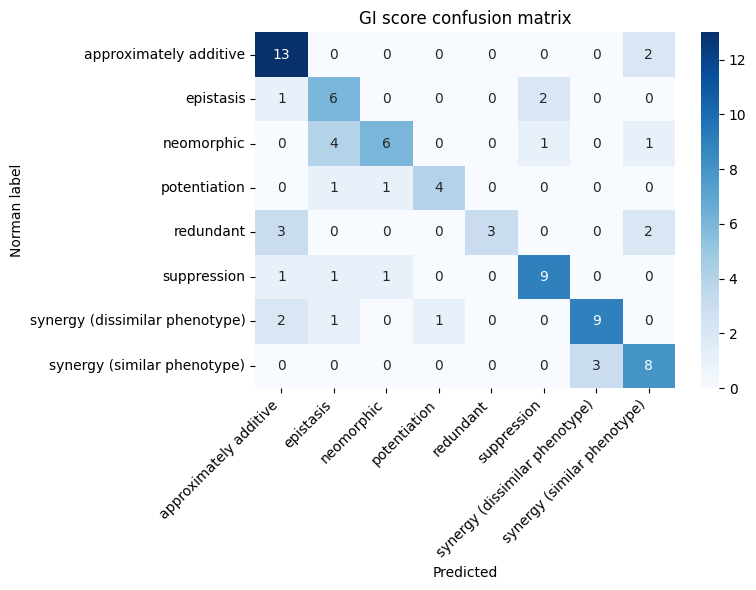

In [28]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def classify_and_report_gi(
    syn_df,
    gt_path="./genetic_interactions.csv",
    pred_col="predicted_gi",
    inplace=True,
    figsize=(8, 6),
):
    def canon_pair(s):
        s = str(s)
        if "+" not in s:
            return s
        a, b = s.split("+", 1)
        return "+".join(sorted([a.strip(), b.strip()]))

    if not os.path.exists(gt_path):
        raise FileNotFoundError(f"Expected {gt_path} for Norman labels.")

    gt = pd.read_csv(gt_path)
    gt["combination"] = gt["combination"].map(canon_pair)
    gt["genetic_interaction"] = gt["genetic_interaction"].astype(str).str.strip()

    eval_combinations = set(gt["combination"])
    syn_combinations = (
        syn_df["pert_a"].astype(str) + "+" + syn_df["pert_b"].astype(str)
    ).map(canon_pair)

    classified = slk.tl.classify_gi(
        syn_df,
        pred_col=pred_col,
        fit_mask=syn_combinations.isin(eval_combinations),
        inplace=inplace,
    )

    score_df = classified.copy()
    score_df["combination"] = syn_combinations
    score_df = score_df.merge(
        gt[["combination", "genetic_interaction"]],
        on="combination",
        how="inner",
    )
    score_df = score_df.loc[score_df[pred_col].notna()].copy()

    y_true = score_df["genetic_interaction"].astype(str)
    y_pred = score_df[pred_col].astype(str)
    labels = sorted(y_true.unique())

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=labels)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels)

    print(f"Evaluated {len(score_df)} labeled interactions.")
    print(f"Accuracy:    {acc:.3f}")
    print(f"Macro F1:    {macro_f1:.3f}")
    print(f"Weighted F1: {weighted_f1:.3f}")
    print()
    print("Classification report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Norman label")
    ax.set_title("GI score confusion matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return classified

syn = classify_and_report_gi(syn)
# gears_gi = classify_and_report_gi(gears_gi)


In [29]:
def canon_pair(s):
    s = str(s)
    if "+" not in s:
        return s
    a, b = s.split("+", 1)
    return "+".join(sorted([a.strip(), b.strip()]))

gi_labels = pd.read_csv('./genetic_interactions.csv', index_col=0)

# Canonicalize syn combination keys
syn.index = (
    syn['pert_a'].astype(str) + "+" + syn['pert_b'].astype(str)
).map(canon_pair)

gi_labels.index = gi_labels.index.astype(str).map(canon_pair)

# Assign genetic_interaction from gi_labels to syn.gt_gi
syn['gt_gi'] = syn.index.map(gi_labels['genetic_interaction'])

# Compute accuracy for non-NA values
valid = syn['gt_gi'].notna() & syn['predicted_gi'].notna()
accuracy = (syn.loc[valid, 'predicted_gi'] == syn.loc[valid, 'gt_gi']).mean()

print(f"Matched rows: {valid.sum()}")
print(f"Accuracy: {accuracy:.4f}")

Matched rows: 86
Accuracy: 0.6744


Held-out combinations absent from adata_train: 24
Evaluated 22 labeled held-out interactions.
Accuracy:    0.636
Macro F1:    0.618
Weighted F1: 0.641

Classification report:
                                precision    recall  f1-score   support

        approximately additive       1.00      1.00      1.00         4
                     epistasis       0.33      0.50      0.40         2
                    neomorphic       0.67      0.67      0.67         3
                  potentiation       1.00      0.50      0.67         2
                     redundant       1.00      0.50      0.67         2
                   suppression       0.50      0.67      0.57         3
synergy (dissimilar phenotype)       0.50      0.67      0.57         3
   synergy (similar phenotype)       0.50      0.33      0.40         3

                      accuracy                           0.64        22
                     macro avg       0.69      0.60      0.62        22
                  weighted avg 

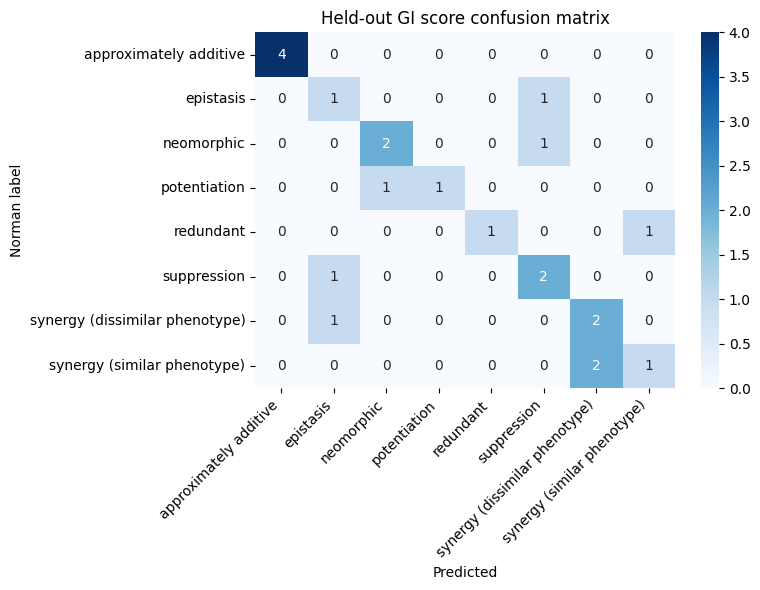

Held-out combinations absent from adata_train: 24
Evaluated 22 labeled held-out interactions.
Accuracy:    0.409
Macro F1:    0.377
Weighted F1: 0.371

Classification report:
                                precision    recall  f1-score   support

        approximately additive       0.33      0.50      0.40         4
                     epistasis       0.50      0.50      0.50         2
                    neomorphic       0.67      0.67      0.67         3
                  potentiation       0.50      0.50      0.50         2
                     redundant       0.20      0.50      0.29         2
                   suppression       0.67      0.67      0.67         3
synergy (dissimilar phenotype)       0.00      0.00      0.00         3
   synergy (similar phenotype)       0.00      0.00      0.00         3

                      accuracy                           0.41        22
                     macro avg       0.36      0.42      0.38        22
                  weighted avg 

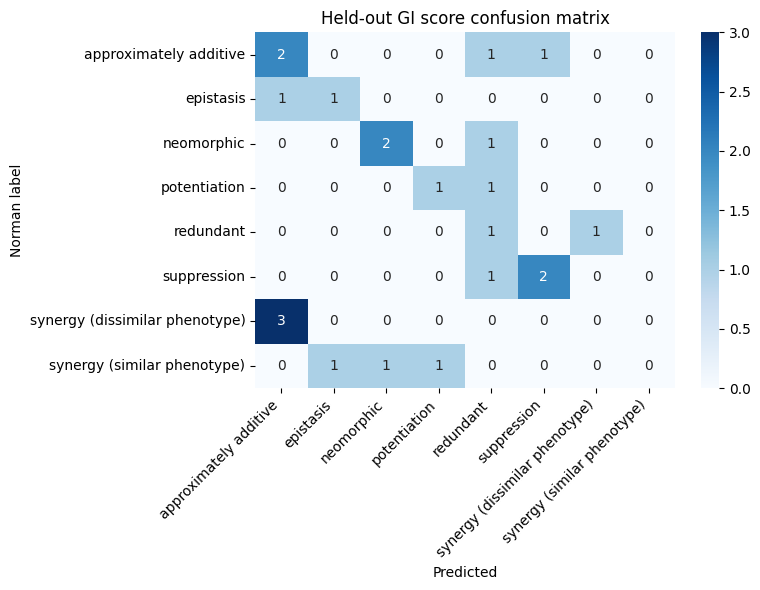

In [30]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


def classify_and_report_unseen_gi(
    syn_df,
    adata_train,
    gt_path="./genetic_interactions.csv",
    pred_col="predicted_gi",
    inplace=True,
    figsize=(8, 6),
):
    def canon_pair(s):
        s = str(s)
        if "+" not in s:
            return s
        a, b = s.split("+", 1)
        return "+".join(sorted([a.strip(), b.strip()]))

    if not os.path.exists(gt_path):
        raise FileNotFoundError(f"Expected {gt_path} for Norman labels.")

    gt = pd.read_csv(gt_path)
    gt["combination"] = gt["combination"].map(canon_pair)
    gt["genetic_interaction"] = gt["genetic_interaction"].astype(str).str.strip()

    train_combinations = set(
        adata_train.obs[p_key]
        .astype(str)
        .loc[lambda s: s.str.contains("+", regex=False)]
        .map(canon_pair)
    )
    unseen_combinations = set(gt["combination"]) - train_combinations

    syn_combinations = (
        syn_df["pert_a"].astype(str) + "+" + syn_df["pert_b"].astype(str)
    ).map(canon_pair)
    labeled_mask = syn_combinations.isin(set(gt["combination"]))

    classified = slk.tl.classify_gi(
        syn_df,
        pred_col=pred_col,
        fit_mask=labeled_mask,
        inplace=inplace,
    )

    score_df = classified.copy()
    score_df["combination"] = syn_combinations
    score_df = score_df.loc[score_df["combination"].isin(unseen_combinations)].copy()
    score_df = score_df.merge(
        gt[["combination", "genetic_interaction"]],
        on="combination",
        how="inner",
    )
    score_df = score_df.loc[score_df[pred_col].notna()].copy()

    y_true = score_df["genetic_interaction"].astype(str)
    y_pred = score_df[pred_col].astype(str)
    labels = sorted(y_true.unique())

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=labels)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels)

    print(f"Held-out combinations absent from adata_train: {len(unseen_combinations)}")
    print(f"Evaluated {len(score_df)} labeled held-out interactions.")
    print(f"Accuracy:    {acc:.3f}")
    print(f"Macro F1:    {macro_f1:.3f}")
    print(f"Weighted F1: {weighted_f1:.3f}")
    print()
    print("Classification report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Norman label")
    ax.set_title("Held-out GI score confusion matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return classified

syn = classify_and_report_unseen_gi(syn, data_train)
gears_gi = classify_and_report_unseen_gi(gears_gi, data_train)


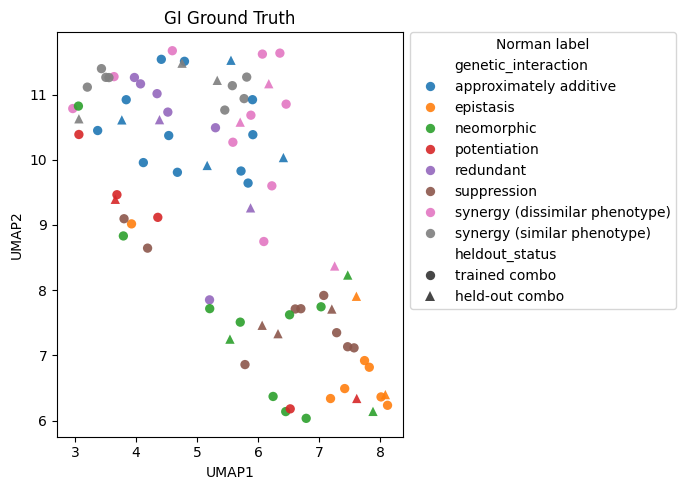

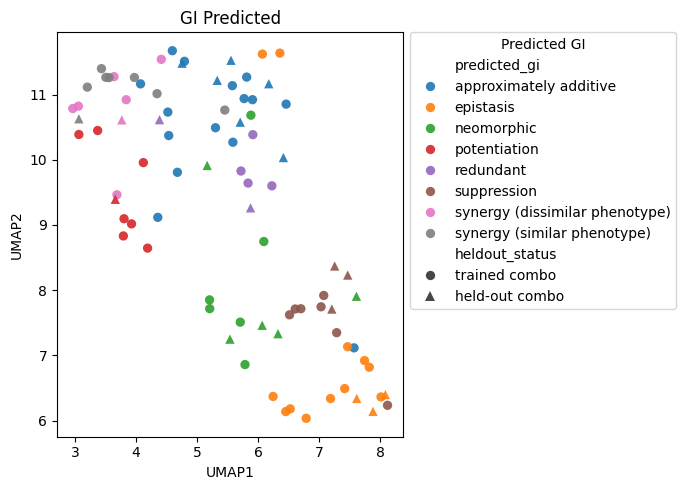

Plotted 86 interactions using 12 metrics.
Held-out combos plotted: 22
Helper metrics: ['singles_to_doubles', 'additive_residual_norm', 'dominance', 'parent_dcor_diff', 'equality_contribution', 'singles_similarity', 'norm_ab_over_additive', 'norm_fit_over_ab', 'magnitude', 'model_fit_dcor', 'norm_fit', 'signed_residual_alignment']


,combination,genetic_interaction,predicted_gi,singles_to_doubles,additive_residual_norm,dominance,parent_dcor_diff,equality_contribution,singles_similarity,norm_ab_over_additive,norm_fit_over_ab,magnitude,model_fit_dcor,norm_fit,signed_residual_alignment,umap_1,umap_2,heldout_status
0,AHR+FEV,synergy (dissimilar phenotype),synergy (dissimilar phenotype),0.843164,0.558316,0.147277,0.005011,0.993485,0.529614,1.289889,0.850855,1.678721,0.885181,21.050716,0.677296,3.641600,11.274316,trained combo
1,AHR+KLF1,epistasis,potentiation,0.761505,0.339167,0.177999,0.364593,0.518501,0.144801,1.087653,0.866494,1.276844,0.944666,11.182552,0.403939,3.928307,9.016523,trained combo
6,BPGM+SAMD1,approximately additive,neomorphic,0.855569,0.449552,0.374953,0.112487,0.864815,0.651376,0.887826,0.707559,0.911350,0.861408,7.527442,-0.012112,5.167830,9.912246,held-out combo
10,CBFA2T3+FEV,potentiation,potentiation,0.665056,1.379277,0.020527,0.239428,0.623384,0.191559,2.045700,0.780812,2.213215,0.724348,22.447607,0.901495,3.066000,10.387204,trained combo
11,CBFA2T3+POU3F2,synergy (dissimilar phenotype),synergy (dissimilar phenotype),0.821026,0.848406,0.892038,0.246137,0.699928,0.510849,1.453995,0.910274,1.863961,0.831506,12.873610,0.743323,2.965567,10.784811,trained combo


In [ ]:
# Regular 2D UMAP using Norman six plus top one-vs-rest CSV separators
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

try:
    from umap import UMAP
except ImportError as exc:
    raise ImportError(
        "This cell needs umap-learn. Install it with `pip install umap-learn` "
        "in the notebook environment, then rerun the cell."
    ) from exc


norman6_metrics = [
    "magnitude",
    "dominance",
    "model_fit_r2_centered",
    "singles_similarity",
    "singles_to_doubles",
    "equality_contribution",
]

helper_metrics = [
    "singles_to_doubles",
    "additive_residual_norm",
    "dominance",
    "parent_dcor_diff",
    "equality_contribution",
    "singles_similarity",
    "norm_ab_over_additive",
    "norm_fit_over_ab",
    "magnitude",
    "model_fit_dcor",
    "norm_fit",
    "signed_residual_alignment",
]

umap_metrics = helper_metrics

def canon_pair(s):
    s = str(s)
    if "+" not in s:
        return s
    a, b = s.split("+", 1)
    return "+".join(sorted([a.strip(), b.strip()]))

plot_df = syn.copy()
plot_df["combination"] = (
    plot_df["pert_a"].astype(str) + "+" + plot_df["pert_b"].astype(str)
).map(canon_pair)

# if "signed_residual_alignment" not in plot_df.columns and "cos_add_resid_ab" in plot_df.columns:
#     print("Using cos_add_resid_ab as a fallback for signed_residual_alignment; rerun get_gi for the exact metric.")
#     plot_df["signed_residual_alignment"] = plot_df["cos_add_resid_ab"]

missing = [c for c in umap_metrics if c not in plot_df.columns]
if missing:
    raise ValueError(f"Missing UMAP metric columns in syn: {missing}")

if "model_corr" not in plot_df.columns:
    print(
        "Rerun get_gi to refresh syn with Norman-style OLS coefficients and R2 model_fit; "
        "this syn may still contain the older robust/correlation fit."
    )

if os.path.exists("./genetic_interactions.csv"):
    gt = pd.read_csv("./genetic_interactions.csv")
    gt["combination"] = gt["combination"].map(canon_pair)
    gt["genetic_interaction"] = gt["genetic_interaction"].astype(str).str.strip()
    plot_df = plot_df.merge(
        gt[["combination", "genetic_interaction"]],
        on="combination",
        how="left",
    )
else:
    plot_df["genetic_interaction"] = "unlabeled"

if "predicted_gi" not in plot_df.columns:
    raise ValueError("Run the GI classification cell before this UMAP cell so syn['predicted_gi'] is available.")

valid = np.isfinite(plot_df[umap_metrics]).all(axis=1)
if valid.sum() < 3:
    raise ValueError(f"Need at least 3 finite rows for UMAP; found {valid.sum()}.")

X = StandardScaler().fit_transform(plot_df.loc[valid, umap_metrics].astype(float))
embedding = UMAP(
    n_components=2,
    n_neighbors=20,
    # min_dist=0.3,
    metric="euclidean",
    random_state=42,
).fit_transform(X)

gi_metric_umap_all = plot_df.loc[
    valid,
    ["combination", "genetic_interaction", "predicted_gi"] + umap_metrics,
].copy()
gi_metric_umap_all["umap_1"] = embedding[:, 0]
gi_metric_umap_all["umap_2"] = embedding[:, 1]

train_combos = {
    canon_pair(pert)
    for pert in data_train.obs[p_key].astype(str).unique()
    if "+" in pert
}
gi_metric_umap_all["heldout_status"] = np.where(
    gi_metric_umap_all["combination"].isin(train_combos),
    "trained combo",
    "held-out combo",
)

plot_valid = (
    gi_metric_umap_all["genetic_interaction"].notna()
    & gi_metric_umap_all["predicted_gi"].notna()
)
gi_metric_umap = gi_metric_umap_all.loc[plot_valid].copy()

label_values = pd.concat([
    gi_metric_umap["genetic_interaction"],
    gi_metric_umap["predicted_gi"],
]).dropna().astype(str)
label_order = sorted(label_values.unique())
label_palette = dict(zip(label_order, sns.color_palette("tab10", n_colors=len(label_order))))

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=gi_metric_umap,
    x="umap_1",
    y="umap_2",
    hue="genetic_interaction",
    hue_order=label_order,
    palette=label_palette,
    style="heldout_status",
    style_order=["trained combo", "held-out combo"],
    markers={"trained combo": "o", "held-out combo": "^"},
    s=45,
    alpha=0.9,
    linewidth=0,
    ax=ax,
)
ax.set_title("GI Ground Truth")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(title="Norman label", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=gi_metric_umap,
    x="umap_1",
    y="umap_2",
    hue="predicted_gi",
    hue_order=label_order,
    palette=label_palette,
    style="heldout_status",
    style_order=["trained combo", "held-out combo"],
    markers={"trained combo": "o", "held-out combo": "^"},
    s=45,
    alpha=0.9,
    linewidth=0,
    ax=ax,
)
ax.set_title("GI Predicted")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(title="Predicted GI", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

print(f"Plotted {len(gi_metric_umap)} interactions using {len(umap_metrics)} metrics.")
print("Held-out combos plotted:", int((gi_metric_umap["heldout_status"] == "held-out combo").sum()))
print("Helper metrics:", helper_metrics)
gi_metric_umap.head()


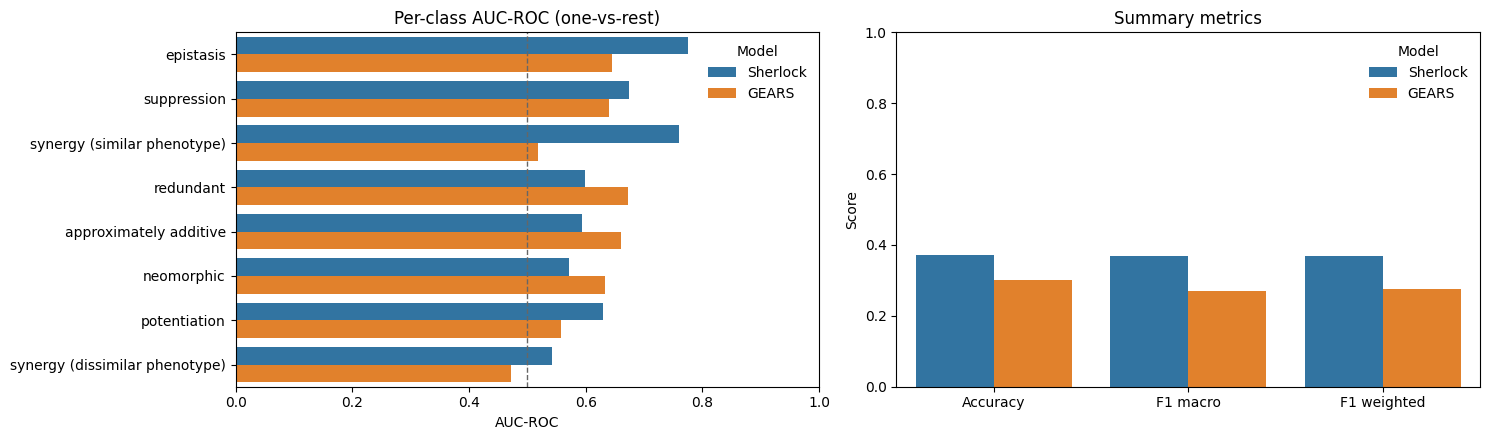

In [25]:
from sklearn.metrics import roc_auc_score, f1_score


def canon_pair(s):
    s = str(s)
    if "+" not in s:
        return s
    a, b = s.split("+", 1)
    return "+".join(sorted([a.strip(), b.strip()]))


def gi_combinations(df):
    if "combination" in df.columns:
        return df["combination"].astype(str).map(canon_pair)
    if {"pert_a", "pert_b"}.issubset(df.columns):
        return (df["pert_a"].astype(str) + "+" + df["pert_b"].astype(str)).map(canon_pair)
    return pd.Series(df.index.astype(str), index=df.index).map(canon_pair)


def evaluate_gi_predictions(df, model_name, gt):
    work = df.copy()
    combos = gi_combinations(work)
    eval_combinations = set(gt["combination"])
    work = slk.tl.classify_gi(
        work,
        fit_mask=combos.isin(eval_combinations),
        inplace=True,
    )
    work["combination"] = combos
    eval_df = work.merge(
        gt[["combination", "genetic_interaction"]],
        on="combination",
        how="inner",
    )
    eval_df = eval_df.loc[eval_df["predicted_gi"].notna()].copy()

    y_true = eval_df["genetic_interaction"].astype(str)
    y_pred = eval_df["predicted_gi"].astype(str)
    labels = sorted(set(y_true.unique()) | set(y_pred.unique()))

    summary = pd.DataFrame([
        {"model": model_name, "metric": "Accuracy", "score": float((y_true == y_pred).mean())},
        {"model": model_name, "metric": "F1 macro", "score": f1_score(y_true, y_pred, average="macro", zero_division=0)},
        {"model": model_name, "metric": "F1 weighted", "score": f1_score(y_true, y_pred, average="weighted", zero_division=0)},
    ])

    auc_rows = []
    for cls in labels:
        true_bin = (y_true == cls).astype(int)
        pred_bin = (y_pred == cls).astype(int)
        n_pos = int(true_bin.sum())
        auc = roc_auc_score(true_bin, pred_bin) if 0 < n_pos < len(true_bin) else np.nan
        auc_rows.append({
            "model": model_name,
            "class": cls,
            "n_positive": n_pos,
            "f1": f1_score(true_bin, pred_bin, zero_division=0),
            "auc_roc": auc,
        })
    return eval_df, pd.DataFrame(auc_rows), summary


gi = pd.read_csv("./genetic_interactions.csv")
gi["combination"] = gi["combination"].map(canon_pair)
gi["genetic_interaction"] = gi["genetic_interaction"].astype(str).str.strip()

_eval_frames = []
_auc_frames = []
_summary_frames = []
for _name, _df in [("Sherlock", syn), ("GEARS", gears_gi)]:
    _eval_df, _auc_df, _summary_df = evaluate_gi_predictions(_df, _name, gi)
    _eval_frames.append(_eval_df.assign(model=_name))
    _auc_frames.append(_auc_df)
    _summary_frames.append(_summary_df)

gi_auc_eval = pd.concat(_eval_frames, ignore_index=True)
gi_auc_df = pd.concat(_auc_frames, ignore_index=True)
gi_summary_df = pd.concat(_summary_frames, ignore_index=True)

class_order = (
    gi_auc_df.groupby("class")["auc_roc"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)
metric_order = ["Accuracy", "F1 macro", "F1 weighted"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(
    data=gi_auc_df,
    y="class",
    x="auc_roc",
    hue="model",
    order=class_order,
    ax=axes[0],
)
axes[0].axvline(0.5, color="0.4", linestyle="--", linewidth=1)
axes[0].set_xlabel("AUC-ROC")
axes[0].set_ylabel("")
axes[0].set_title("Per-class AUC-ROC (one-vs-rest)")
axes[0].set_xlim(0, 1)
axes[0].legend(title="Model", frameon=False)

sns.barplot(
    data=gi_summary_df,
    x="metric",
    y="score",
    hue="model",
    order=metric_order,
    ax=axes[1],
)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("")
axes[1].set_ylabel("Score")
axes[1].set_title("Summary metrics")
axes[1].legend(title="Model", frameon=False)

plt.tight_layout()
plt.show()


## UMAP of perturbed latent z  (single perturbations only)

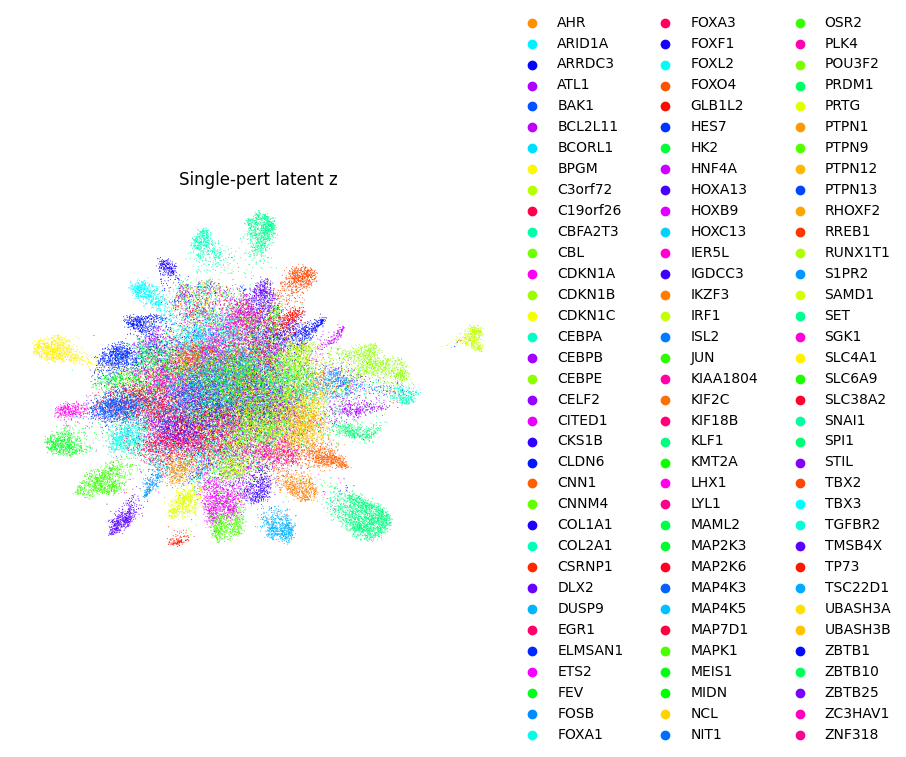

In [ ]:
import random

single_mask = (
    (data.obs[p_key] != NTC) &
    (~data.obs['perturbation_name'].astype(str).str.contains(r'\+', regex=True))
)
sub = data[single_mask].copy()

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

n_cats  = sub.obs[p_key].nunique()
palette = sns.color_palette('hsv', n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color=p_key, palette=palette, frameon=False, title='Single-pert latent z')

## Perturbation embedding correlation (rho_corr)

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


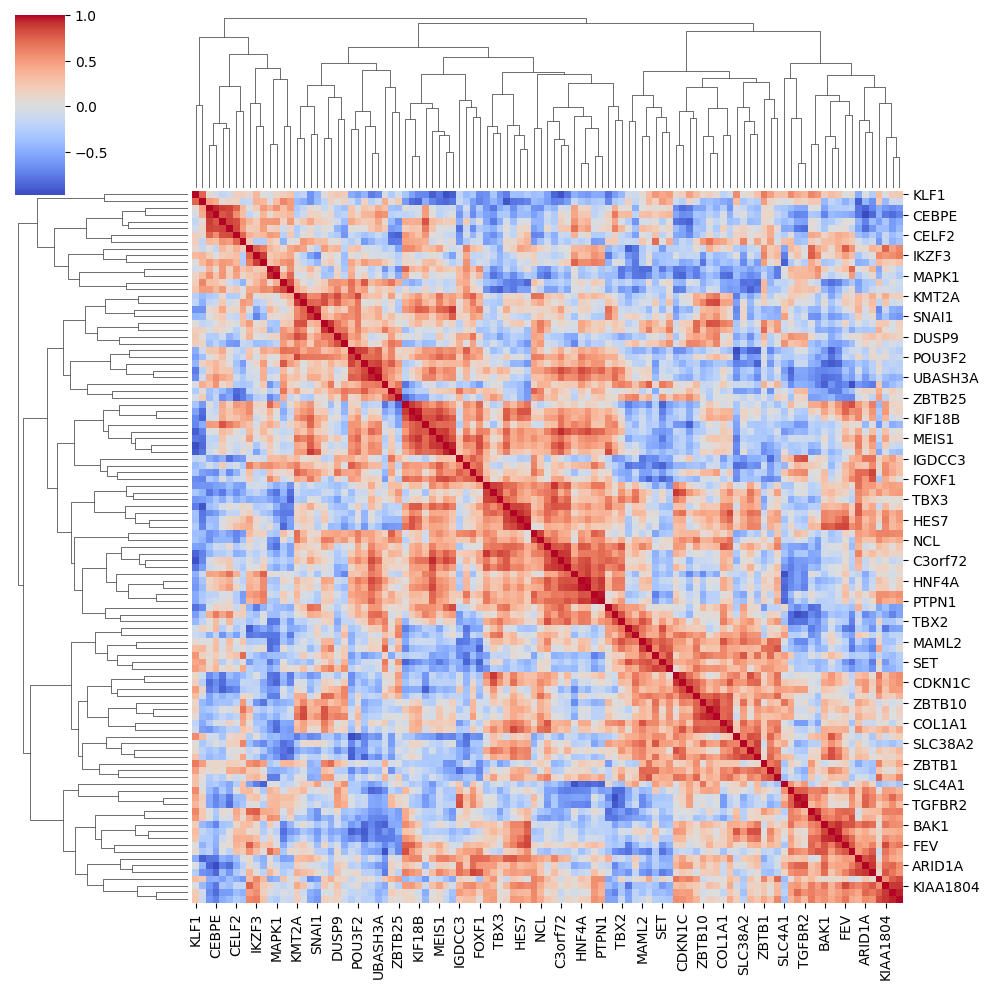

In [29]:
slk.pl.plot_corr(data)

## ATE — counterfactual effect prediction

**Protocol**
1. Encode NTC cells → background `z0_i`
2. K-means centroids `c_k` in background space (K=25)
3. For each perturbation `p`:  
   — single: `z_cf = c_k * (1 − W[p]) + A[p]*W[p]`  
   — combo `A+B`: `z_cf = c_k * (1 − max(W_A, W_B)) + A_A*W_A + A_B*W_B`
4. Decode → expected counts, log2-CPM normalise, subtract NTC baseline
5. Pearson r vs observed `treat_effect`

In [ ]:
ate = model.predict_counterfactual_effects(
    data,
    n_centroids=25,
    observed_effect=data.uns['treat_effect'],
)
print(f"Pearson r (predicted vs observed ATE, all perts): {ate['corr']:.4f}")

Pearson r (predicted vs observed ATE, all perts): 0.6568


In [ ]:
# Break down by single vs combo perturbations
from scipy.stats import pearsonr

pred_df = ate['predicted_df']
obs_df  = ate['observed_df']

single_idx = [p for p in pred_df.index if '+' not in str(p)]
combo_idx  = [p for p in pred_df.index if '+' in str(p)]

def _r(idx):
    if not idx:
        return float('nan')
    x = pred_df.loc[idx].values.ravel()
    y = obs_df.loc[idx].values.ravel()
    v = np.isfinite(x) & np.isfinite(y)
    return pearsonr(x[v], y[v])[0] if v.sum() > 2 else float('nan')

print(f"  Single perts ({len(single_idx):3d}): Pearson r = {_r(single_idx):.4f}")
print(f"  Combo  perts ({len(combo_idx):3d}): Pearson r = {_r(combo_idx):.4f}")

  Single perts (105): Pearson r = 0.5067
  Combo  perts (131): Pearson r = 0.7041


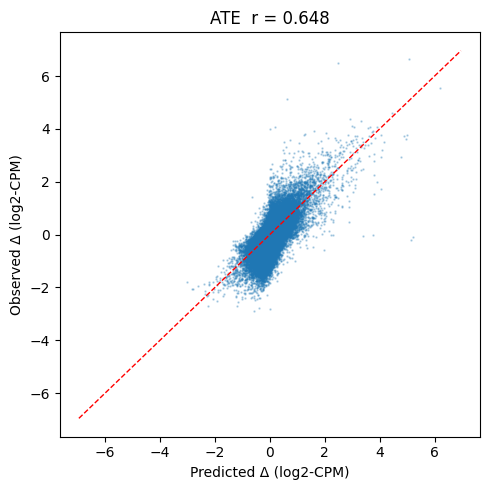

In [ ]:
# Scatter: predicted vs observed ATE (all perts, flattened over genes)
x_flat = pred_df.values.ravel()
y_flat = obs_df.values.ravel()
valid  = np.isfinite(x_flat) & np.isfinite(y_flat)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_flat[valid], y_flat[valid], s=0.5, alpha=0.3, rasterized=True)
lim = max(abs(x_flat[valid]).max(), abs(y_flat[valid]).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
ax.set_xlabel('Predicted Δ (log2-CPM)')
ax.set_ylabel('Observed Δ (log2-CPM)')
ax.set_title(f'ATE  r = {ate["corr"]:.3f}')
plt.tight_layout()
plt.show()

## z_corr vs rho_corr consistency

In [30]:
from scipy.stats import pearsonr, spearmanr

z_corr   = data.uns['results']['z_corr']
rho_corr = data.uns['results']['rho_corr']

pearson  = pearsonr(z_corr.flatten(),  rho_corr.flatten())
spearman = spearmanr(z_corr.flatten(), rho_corr.flatten())
print(f"Spearman ρ = {spearman.statistic:.3f}  (p = {spearman.pvalue:.1e})")
print(f" Pearson  r = {pearson.statistic:.3f}  (p = {pearson.pvalue:.1e})")

Spearman ρ = 0.659  (p = 0.0e+00)
 Pearson  r = 0.676  (p = 0.0e+00)


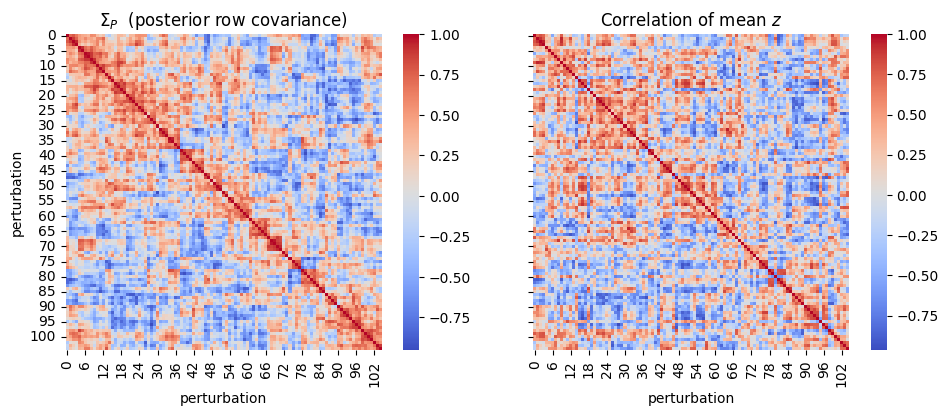

In [ ]:
slk.pl.plot_zcorr(data)

## Gate W analysis

`W[p]` is a HardConcrete gate of shape `(P, d)`. Near-binary values indicate the model has learned sparse, perturbation-specific latent dimensions.

W shape: (105, 16)


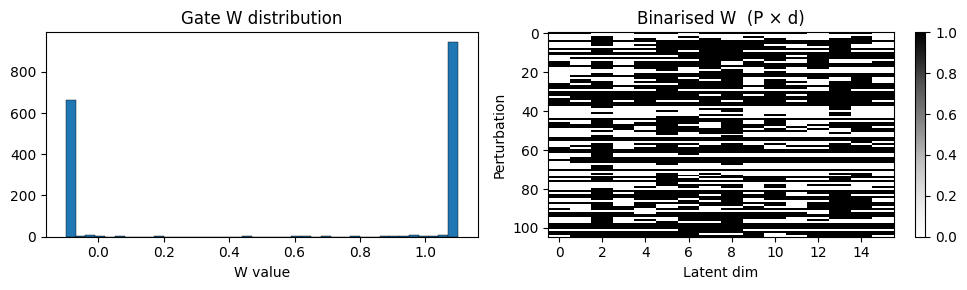

Avg active dims per pert: 9.4 / 16


In [31]:
W = data.uns['results']['W']   # (P, latent_dim)
print(f"W shape: {W.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(W.flatten(), bins=40, edgecolor='k', linewidth=0.3)
axes[0].set_title('Gate W distribution')
axes[0].set_xlabel('W value')

W_bin = (W > 0.5).astype(float)
im = axes[1].imshow(W_bin, aspect='auto', cmap='Greys', interpolation='nearest')
axes[1].set_title('Binarised W  (P × d)')
axes[1].set_xlabel('Latent dim')
axes[1].set_ylabel('Perturbation')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Avg active dims per pert: {W_bin.sum(1).mean():.1f} / {W.shape[1]}")

## Perturbation clustering

Cluster `rho_corr` (correlation of learned `A[p]` vectors) and visualise groups on the single-pert UMAP.

In [ ]:
rho_perts = data.uns['results']['rho_perts']
C = rho_corr
print(f"rho_corr: {C.shape}  |  perts: {len(rho_perts)}")

rho_corr: (105, 105)  |  perts: 105


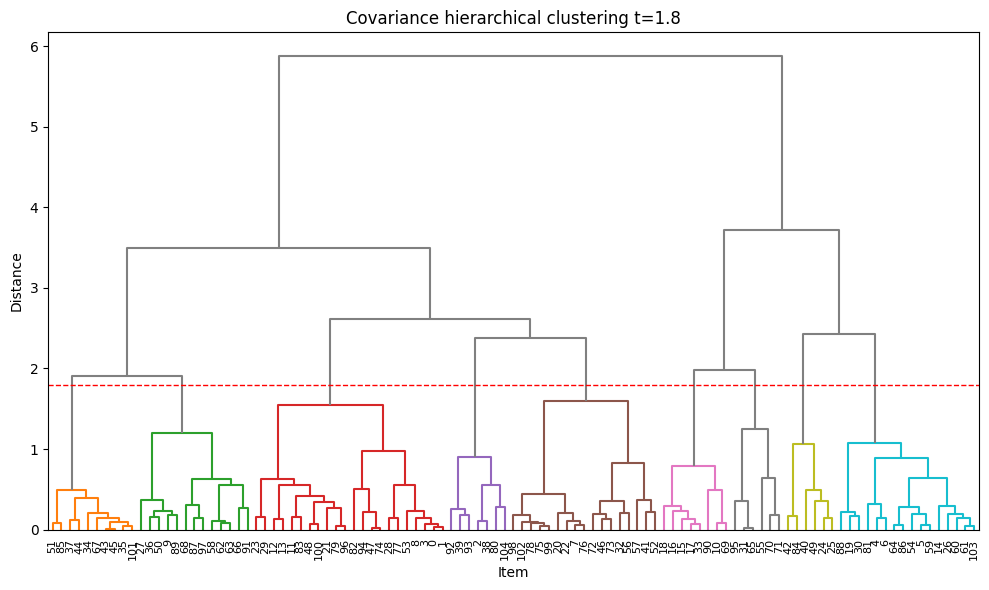

,group
AHR,3
ARID1A,3
ARRDC3,4
ATL1,3
BAK1,9
...,...
ZBTB1,3
ZBTB10,1
ZBTB25,5
ZC3HAV1,9


In [ ]:
groups       = slk.tl.cluster_rho(data, t=1.8, rho_corr=C, show=True)
named_groups = slk.tl.group2name(groups, list(rho_perts))
named_groups

pert_group
1     4557
2     6828
3    11248
4     3530
5     8490
6     4741
7     5575
8     2698
9    10068
Name: count, dtype: int64


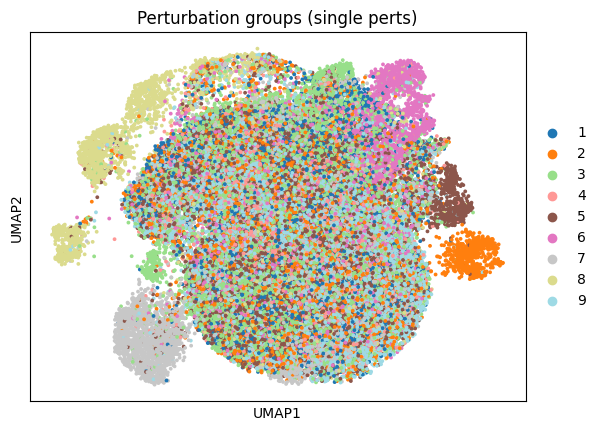

In [ ]:
# Colour single-pert UMAP by learned perturbation group
gene_to_group = named_groups['group'].to_dict()
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group).fillna(-1).astype('category')

print(sub.obs['pert_group'].value_counts().sort_index())
sc.pl.umap(sub, color=['pert_group'], title='Perturbation groups (single perts)', palette='tab20', size=30)

## Synergy scoring

In [ ]:
erythroid = [
    # Globins
    "HBA1", "HBA2", "HBB", "HBG1", "HBG2", "HBE1", "HBZ", "HBD",
    # Membrane/structural
    "GYPA", "GYPB", "GYPC", "SLC4A1", "EPB42", "EPB41",
    "ANK1", "SPTA1", "SPTB", "RHAG",
    # Heme synthesis
    "ALAS2", "ALAD", "HMBS", "UROS", "UROD", "CPOX", "PPOX", "FECH", "TMEM14C",
    # Iron/chaperone
    "AHSP", "TFRC", "SLC25A37", "STEAP3", "FTH1", "FTL",
    # Transcription factors
    "KLF1", "GATA1", "TAL1", "ZFPM1", "NFE2", "LMO2", "MYB",
    # Signaling
    "EPOR", "STAT5A",
    # Metabolism
    "CA1", "CA2", "PKLR", "BPGM", "KCNN4",
    # Maturation
    "BNIP3L",
]

myeloid = [
    "SPI1", "CEBPA", "CEBPB", "CEBPE",
    "MPO", "ELANE", "LYZ", "S100A8", "S100A9", "CSF3R"
]

ifn_stress = [
    "IRF1", "STAT1", "ISG15", "IFIT1", "IFIT2", "IFIT3",
    "MX1", "OAS1", "DDIT3", "HSPA1A"
]

proliferation = [
    "MKI67", "TOP2A", "PCNA", "MCM2", "MCM3", "MCM4",
    "MCM5", "MCM6", "MCM7"
]

gene_sets = {
    "erythroid": erythroid,
    "myeloid": myeloid,
    "ifn_stress": ifn_stress,
    "proliferation": proliferation,
}

for name, genes in gene_sets.items():
    genes = [g for g in genes if g in data.var_names]
    sc.tl.score_genes(data, genes, score_name=f"{name}_score")

In [ ]:
import pandas as pd
import numpy as np

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

SYN_COLOR = '#2166ac'
EPI_COLOR = '#d73027'

# ── Synergy DataFrame — z-score residuals separately ──────────────────
syn = pd.DataFrame(data.uns['results']['synergy'])
pr  = syn['proj_residual'].values.astype(float)
dr  = syn['dom_residual'].values.astype(float)
ist = syn['interaction_score'].values.astype(float)
syn['proj_residual_z']    = (pr  - np.nanmean(pr))  / (np.nanstd(pr)  + 1e-10)
syn['dom_residual_z']     = (dr  - np.nanmean(dr))  / (np.nanstd(dr)  + 1e-10)
syn['interaction_score_z'] = (ist - np.nanmean(ist)) / (np.nanstd(ist) + 1e-10)

def _find_pair(df, a, b):
    for k in [f"{a}+{b}", f"{b}+{a}"]:
        if k in df.index:
            return k
    return None

required_syn_key = _find_pair(syn, 'CBL', 'CNN1')
required_epi_key = (_find_pair(syn, 'DUSP9', 'ETS1') or _find_pair(syn, 'DUSP9', 'ETS2'))

# Synergy: top proj_residual; Epistasis: top dom_residual
syn_cands = syn[syn['classification'] == 'latent synergy candidate']\
    .sort_values('proj_residual', ascending=False)
epi_cands = syn[syn['classification'] == 'dominance epistasis']\
    .sort_values('dom_residual', ascending=False)

def _build_list(required, pool, n=5):
    out = [required] if required and required in syn.index else []
    for idx in pool.index:
        if idx not in out and len(out) < n:
            out.append(idx)
    return out

syn_pairs    = _build_list(required_syn_key, syn_cands)
epi_pairs    = _build_list(required_epi_key, epi_cands)
selected     = syn_pairs + epi_pairs
selected_syn = set(syn_pairs)
selected_epi = set(epi_pairs)

print("Synergy pairs:  ", syn_pairs)
print("Epistatic pairs:", epi_pairs)

# ── NTC-centred deltas ─────────────────────────────────────────────────
z          = data.obsm['z']
pert_obs   = data.obs[p_key].astype(str).values
mean_z_ntc = z[pert_obs == NTC].mean(0)

def _delta(p):
    return z[pert_obs == p].mean(0) - mean_z_ntc


Synergy pairs:   ['CBL+CNN1', 'DLX2+ZBTB10', 'CNN1+UBASH3B', 'S1PR2+SGK1', 'CEBPE+SPI1']
Epistatic pairs: ['DUSP9+ETS2', 'ELMSAN1+LHX1', 'IKZF3+MAP2K6', 'ELMSAN1+ZBTB10', 'CEBPA+KLF1']


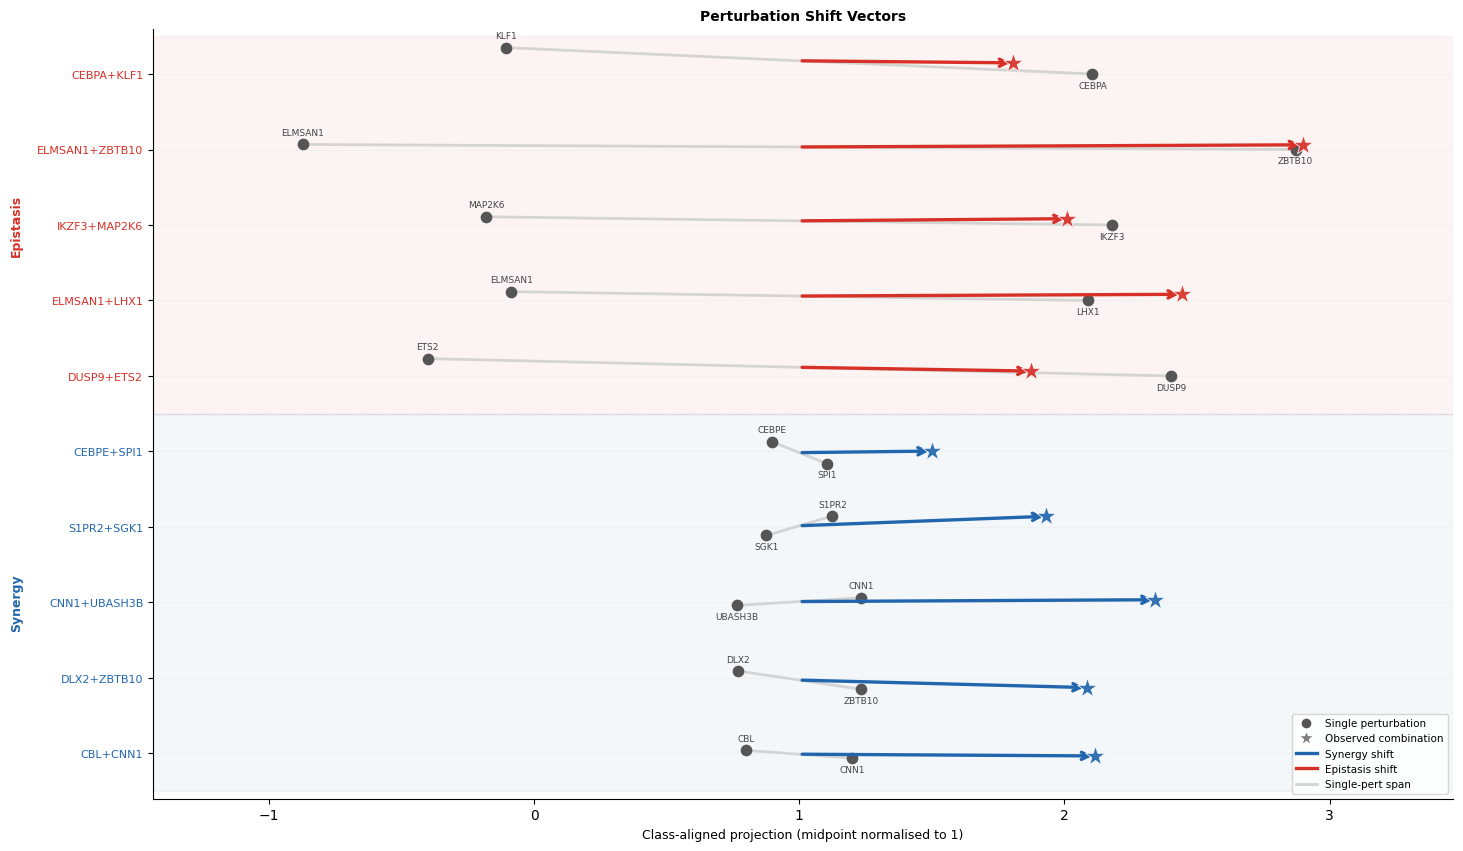

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

_eps = 1e-8

def _unit(x, eps=1e-8):
    x = np.asarray(x, dtype=float)
    n = np.linalg.norm(x)
    return x / n if n > eps else None


def _decompose_full(da, db, dab, mode="shared", dominant_pert=None, pert_a=None, pert_b=None, eps=1e-8):
    ua = _unit(da, eps)
    ub = _unit(db, eps)
    if ua is None or ub is None:
        return None

    if mode == "dominant":
        if dominant_pert == pert_a:
            e1, other = ua, ub
        elif dominant_pert == pert_b:
            e1, other = ub, ua
        else:
            e1, other = _unit(ua + ub, eps), ua - ub
    else:
        e1, other = _unit(ua + ub, eps), ua - ub

    if e1 is None:
        return None

    e2_raw = other - np.dot(other, e1) * e1
    e2 = _unit(e2_raw, eps)
    if e2 is None:
        tmp = np.zeros_like(e1)
        tmp[np.argmin(np.abs(e1))] = 1.0
        e2 = _unit(tmp - np.dot(tmp, e1) * e1, eps)

    def _p(v):
        return float(np.dot(v, e1)), (float(np.dot(v, e2)) if e2 is not None else 0.0)

    de = 0.5 * (da + db)
    return dict(A=_p(da), B=_p(db), E=_p(de), AB=_p(dab),
                interaction_norm=float(np.linalg.norm(dab - de)))


pairs_ordered = syn_pairs + epi_pairs
n_syn   = len(syn_pairs)
n_pairs = len(pairs_ordered)

# Compute decompositions
row_data = []
for pair_key in pairs_ordered:
    row = syn.loc[pair_key]
    na, nb = row['pert_a'], row['pert_b']
    has_data = (pert_obs == na).any() and (pert_obs == nb).any() and (pert_obs == pair_key).any()
    if not has_data:
        row_data.append(None)
        continue
    mode = "dominant" if row['classification'] == "dominance epistasis" else "shared"
    row_data.append(_decompose_full(
        _delta(na), _delta(nb), _delta(pair_key),
        mode=mode, dominant_pert=row.get('dominant_pert'),
        pert_a=na, pert_b=nb, eps=_eps,
    ))

all_y_raw = [r[k][1] for r in row_data if r for k in ('A', 'B', 'E', 'AB')]
y_scale = 0.35 / (max((abs(v) for v in all_y_raw), default=1.0) + _eps)

fig, ax = plt.subplots(figsize=(20, max(6, n_pairs * 0.8 + 2)))

ax.axhspan(-0.5,        n_syn - 0.5,   alpha=0.05, color=SYN_COLOR, zorder=0)
ax.axhspan(n_syn - 0.5, n_pairs - 0.5, alpha=0.05, color=EPI_COLOR, zorder=0)
ax.axhline(n_syn - 0.5, color='#ccc', lw=0.8, linestyle=':', zorder=0)

x_all = []
for row_i, (pair_key, result) in enumerate(zip(pairs_ordered, row_data)):
    color = SYN_COLOR if pair_key in selected_syn else EPI_COLOR
    row   = syn.loc[pair_key]
    na, nb = row['pert_a'], row['pert_b']

    ax.axhline(row_i, color='#eee', lw=0.5, zorder=0)

    if result is None:
        ax.text(1.0, row_i, '(no data)', fontsize=7, ha='center', va='center', color='#aaa')
        continue

    e_x = result['E'][0]
    norm = abs(e_x) + _eps

    A_xn  = result['A'][0]  / norm
    B_xn  = result['B'][0]  / norm
    E_xn  = 1.0
    AB_xn = result['AB'][0] / norm

    A_yp  = row_i + result['A'][1]  * y_scale
    B_yp  = row_i + result['B'][1]  * y_scale
    E_yp  = row_i + result['E'][1]  * y_scale
    AB_yp = row_i + result['AB'][1] * y_scale

    x_all.extend([A_xn, B_xn, AB_xn])

    ax.plot([A_xn, B_xn], [A_yp, B_yp], '-', color='#d4d4d4', lw=2.0, zorder=1, solid_capstyle='round')
    ax.annotate('', xy=(AB_xn, AB_yp), xytext=(E_xn, E_yp),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.4, mutation_scale=13), zorder=4)
    ax.scatter(A_xn,  A_yp,  s=55,  c='#555', marker='o', zorder=3)
    ax.scatter(B_xn,  B_yp,  s=55,  c='#555', marker='o', zorder=3)
    ax.scatter(AB_xn, AB_yp, s=220, c=color,  marker='*', zorder=5,
               edgecolors='white', linewidths=0.6, alpha=0.92)

    va_a = 'bottom' if A_yp >= B_yp else 'top'
    va_b = 'top'    if A_yp >= B_yp else 'bottom'
    ax.annotate(na, (A_xn, A_yp), fontsize=6.5, ha='center', va=va_a,
                xytext=(0, 5 if va_a == 'bottom' else -5), textcoords='offset points', color='#444')
    ax.annotate(nb, (B_xn, B_yp), fontsize=6.5, ha='center', va=va_b,
                xytext=(0, -5 if va_b == 'top' else 5), textcoords='offset points', color='#444')

# Y-axis: just pair names
ax.set_yticks(range(n_pairs))
ax.set_yticklabels(pairs_ordered, fontsize=8)
for tick, pair_key in zip(ax.get_yticklabels(), pairs_ordered):
    tick.set_color(SYN_COLOR if pair_key in selected_syn else EPI_COLOR)

if x_all:
    lo, hi = min(x_all), max(x_all)
    pad = max((hi - lo) * 0.15, 0.3)
    ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(-0.6, n_pairs - 0.4)
ax.set_xlabel('Class-aligned projection (midpoint normalised to 1)', fontsize=9)
ax.set_title('Perturbation Shift Vectors', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# Synergy / Epistasis labels — further left to clear y-tick labels
ax.text(-0.10, (n_syn - 1) / 2, 'Synergy',
        transform=ax.get_yaxis_transform(), fontsize=9, fontweight='bold',
        color=SYN_COLOR, ha='right', va='center', rotation=90)
ax.text(-0.10, n_syn + (n_pairs - n_syn - 1) / 2, 'Epistasis',
        transform=ax.get_yaxis_transform(), fontsize=9, fontweight='bold',
        color=EPI_COLOR, ha='right', va='center', rotation=90)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#555', markersize=8,
           label='Single perturbation'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gray', markersize=12,
           label='Observed combination'),
    Line2D([0], [0], color=SYN_COLOR, lw=2.4, label='Synergy shift'),
    Line2D([0], [0], color=EPI_COLOR, lw=2.4, label='Epistasis shift'),
    Line2D([0], [0], color='#d4d4d4', lw=2.0, label='Single-pert span'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=7.5, frameon=True)

fig.subplots_adjust(left=0.25)
plt.show()


In [ ]:
syn[syn.index.str.contains('OSR2')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,classification,proj_residual_z
CEBPB+OSR2,CEBPB,OSR2,None,487,1002,211,0.518737,0.908942,0.811998,0.987437,1.474980,latent synergy candidate,0.084840
FOSB+OSR2,FOSB,OSR2,None,630,1002,382,0.435361,0.809426,0.876288,0.994920,2.068919,mixed / ambiguous,0.877802
OSR2+PTPN12,OSR2,PTPN12,OSR2,1002,445,338,-0.595607,0.837684,-0.138227,0.777757,0.096475,dominance epistasis,-1.755589
OSR2+UBASH3B,OSR2,UBASH3B,OSR2,1002,1201,795,-0.562060,0.968559,-0.508198,0.491900,-0.056332,dominance epistasis,-1.959601


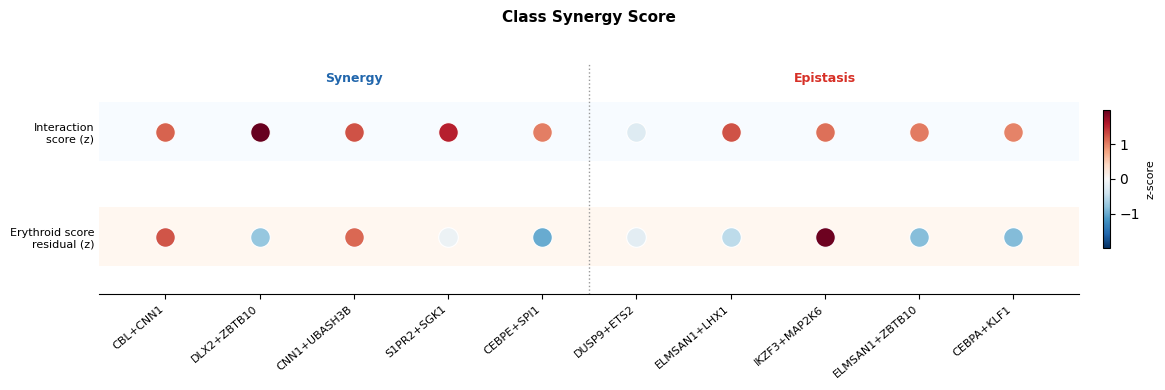

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

pairs       = [p for p in selected if p in syn.index]
n_pairs     = len(pairs)
n_syn_shown = sum(1 for p in pairs if p in selected_syn)

# ── Interaction score z-score (top row) ───────────────────────────────
interaction_z = np.array([float(syn.loc[p, 'interaction_score_z']) for p in pairs])

# ── Erythroid score residual (bottom row) ─────────────────────────────
ery_raw = np.full(n_pairs, np.nan)
for j, pair in enumerate(pairs):
    row = syn.loc[pair]
    na, nb = row['pert_a'], row['pert_b']
    mask_ab = data.obs[p_key] == pair
    mask_a  = data.obs[p_key] == na
    mask_b  = data.obs[p_key] == nb
    if mask_ab.any() and mask_a.any() and mask_b.any():
        ery_raw[j] = (
            data.obs.loc[mask_ab, 'erythroid_score'].mean()
            - 0.5 * (data.obs.loc[mask_a, 'erythroid_score'].mean()
                     + data.obs.loc[mask_b, 'erythroid_score'].mean())
        )

valid = np.isfinite(ery_raw)
if valid.sum() > 1:
    ery_z = (ery_raw - np.nanmean(ery_raw)) / (np.nanstd(ery_raw) + 1e-10)
else:
    ery_z = ery_raw.copy()

# ── Shared diverging colormap across both rows ─────────────────────────
all_z = np.concatenate([interaction_z[np.isfinite(interaction_z)], ery_z[np.isfinite(ery_z)]])
vabs  = float(np.abs(all_z).max()) if len(all_z) > 0 else 1.0
cmap  = plt.cm.RdBu_r
norm  = mcolors.Normalize(vmin=-vabs, vmax=vabs)

DOT_SIZE = 200
x_pos    = np.arange(n_pairs)

fig, ax = plt.subplots(figsize=(max(8, n_pairs * 1.1 + 2), 4))

# Row backgrounds
for y, c in [(1.0, '#f7fbff'), (0.0, '#fff7f0')]:
    ax.axhspan(y - 0.28, y + 0.28, color=c, zorder=0, lw=0)

# Synergy / epistasis divider
if 0 < n_syn_shown < n_pairs:
    ax.axvline(n_syn_shown - 0.5, color='#999', lw=1.0, linestyle=':', zorder=2)

# Top row: interaction score
for j, zv in enumerate(interaction_z):
    c = [cmap(norm(zv))] if np.isfinite(zv) else ['#ddd']
    ax.scatter(j, 1.0, s=DOT_SIZE, c=c, edgecolors='white', linewidths=0.8, zorder=3)

# Bottom row: erythroid score residual
for j, zv in enumerate(ery_z):
    c = [cmap(norm(zv))] if np.isfinite(zv) else ['#ddd']
    ax.scatter(j, 0.0, s=DOT_SIZE, c=c, edgecolors='white', linewidths=0.8, zorder=3)

# Section labels above top row
if n_syn_shown > 0:
    ax.text(n_syn_shown / 2 - 0.5, 1.45, 'Synergy',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=SYN_COLOR)
if n_syn_shown < n_pairs:
    ax.text(n_syn_shown + (n_pairs - n_syn_shown) / 2 - 0.5, 1.45, 'Epistasis',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=EPI_COLOR)

ax.set_yticks([0.0, 1.0])
ax.set_yticklabels(['Erythroid score\nresidual (z)', 'Interaction\nscore (z)'], fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(pairs, rotation=40, ha='right', fontsize=8)
ax.set_xlim(-0.7, n_pairs - 0.3)
ax.set_ylim(-0.55, 1.65)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('z-score', fontsize=8)

ax.set_title('Class Synergy Score', fontsize=11, fontweight='bold', pad=30)
plt.tight_layout()
plt.show()


In [ ]:
syn[syn.index.str.contains('DUSP9')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,dom_residual,interaction_score,classification,proj_residual_z,dom_residual_z,interaction_score_z
DUSP9+ETS2,DUSP9,ETS2,DUSP9,729,1201,786,-0.244707,0.961244,-0.011786,0.772508,0.440797,1.461021,1.647123,dominance epistasis,-1.295887,-0.061679,-0.258339
DUSP9+IGDCC3,DUSP9,IGDCC3,None,729,613,382,0.535926,0.903552,0.830651,0.989464,1.422022,1.300323,1.533467,latent synergy candidate,0.014136,-0.275245,-0.410851
DUSP9+KLF1,DUSP9,KLF1,None,729,1954,366,0.053323,0.653812,0.756149,0.971430,2.416852,2.024684,2.744447,mixed / ambiguous,1.342324,0.687427,1.214145
DUSP9+MAPK1,DUSP9,MAPK1,None,729,763,290,-0.264993,0.714772,0.413991,0.930983,-0.299227,0.078752,0.821201,mixed / ambiguous,-2.283887,-1.898709,-1.366632
DUSP9+PRTG,DUSP9,PRTG,None,729,684,297,0.518618,0.881748,0.854415,0.996211,1.605561,1.392356,1.654632,latent synergy candidate,0.259178,-0.152935,-0.248263
DUSP9+SNAI1,DUSP9,SNAI1,None,729,466,182,0.277514,0.733017,0.811169,0.966055,3.010686,2.961030,3.453320,mixed / ambiguous,2.135147,1.931828,2.165374


<Axes: xlabel='dom_residual', ylabel='Count'>

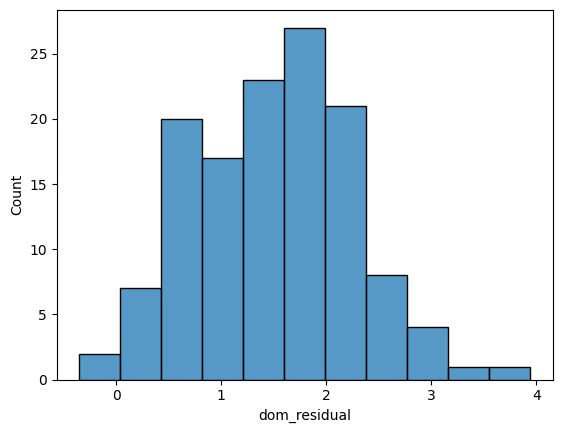

In [ ]:
sns.histplot(syn['dom_residual'])